# Pipeline 5 — Reintegration Readiness Classifier

## Problem Framing

**Business questions**
1. *Which residents are ready to be successfully reintegrated?* → Binary readiness probability (0–100%)
2. *What type of placement is the best fit?* → Multi-class prediction: Family Reunification / Foster Care / Adoption / Independent Living

**Why it matters**
Staff manage 60 cases across 10 safehouses. A data-driven readiness score surfaces who is genuinely ready so no resident stays longer than needed — or leaves before they are stable. The type prediction helps prioritise placement options.

**Two-model design**
| | Model 1 — Readiness | Model 2 — Type |
|---|---|---|
| Target | `reintegration_status == Completed` (binary) | `reintegration_type` (4-class after merging adoptions) |
| Training data | All 60 residents | 19 Completed residents only |
| Causal model | Logistic Regression (coefficients explain *why*) | Logistic Regression |
| Predictive model | Random Forest, Gradient Boosting | Random Forest |
| Validation | Stratified 5-fold CV | Leave-One-Out CV (n=19 too small for hold-out) |
| Primary metric | F1 + AUC-ROC | Macro F1 |

**Data sources**: `residents.csv` (base) + `process_recordings`, `education_records`, `health_wellbeing_records`, `home_visitations`, `incident_reports`, `intervention_plans` — all joined and aggregated at resident level.

**Leakage exclusions**: `date_closed` (only exists for Completed), `case_status` (Closed = Completed), `date_colb_obtained`, `reintegration_type` (excluded from Model 1 target variable engineering).
`current_risk_level` is **included** — crosstab analysis shows its distribution is similar across all status groups (On Hold residents actually have *higher* Low-risk rates than Completed), confirming it is independently assessed and not a proxy for the reintegration decision.


In [141]:
# Install optional dependencies if not present
import subprocess, sys
for pkg in ["shap", "statsmodels"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)


In [142]:
import re, warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut,
    cross_val_score, cross_val_predict,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score,
)
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

DATA_DIR  = Path("../lighthouse_csv_v7")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

POSITIVE_STATES   = {"Hopeful", "Calm", "Happy"}
RISK_ORD          = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
COOP_ORD          = {"Uncooperative": 0, "Neutral": 1, "Cooperative": 2, "Highly Cooperative": 3}
VISIT_OUTCOME_ORD = {"Unfavorable": 0, "Inconclusive": 1, "Needs Improvement": 2, "Favorable": 3}
TYPE_MAP          = {
    "Adoption (Domestic)":      "Adoption",
    "Adoption (Inter-Country)": "Adoption",
    "Family Reunification":     "Family Reunification",
    "Foster Care":              "Foster Care",
    "Independent Living":       "Independent Living",
}


## 1. Data Import

In [143]:
residents  = pd.read_csv(DATA_DIR / "residents.csv")
process_rec = pd.read_csv(DATA_DIR / "process_recordings.csv",    parse_dates=["session_date"])
education   = pd.read_csv(DATA_DIR / "education_records.csv",     parse_dates=["record_date"])
health      = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv", parse_dates=["record_date"])
visitations = pd.read_csv(DATA_DIR / "home_visitations.csv",      parse_dates=["visit_date"])
incidents   = pd.read_csv(DATA_DIR / "incident_reports.csv",      parse_dates=["incident_date"])
iplan       = pd.read_csv(DATA_DIR / "intervention_plans.csv")

for name, df in [
    ("residents", residents), ("process_rec", process_rec),
    ("education", education), ("health", health),
    ("visitations", visitations), ("incidents", incidents),
    ("iplan", iplan),
]:
    print(f"  {name:20s}: {df.shape[0]:>5} rows × {df.shape[1]:>2} cols")


  residents           :    60 rows × 49 cols
  process_rec         :  2819 rows × 15 cols
  education           :   534 rows × 10 cols
  health              :   534 rows × 14 cols
  visitations         :  1337 rows × 14 cols
  incidents           :   100 rows × 12 cols
  iplan               :   180 rows × 11 cols


## 2. Data Understanding — EDA

### 2a. Univariate — Target Variables

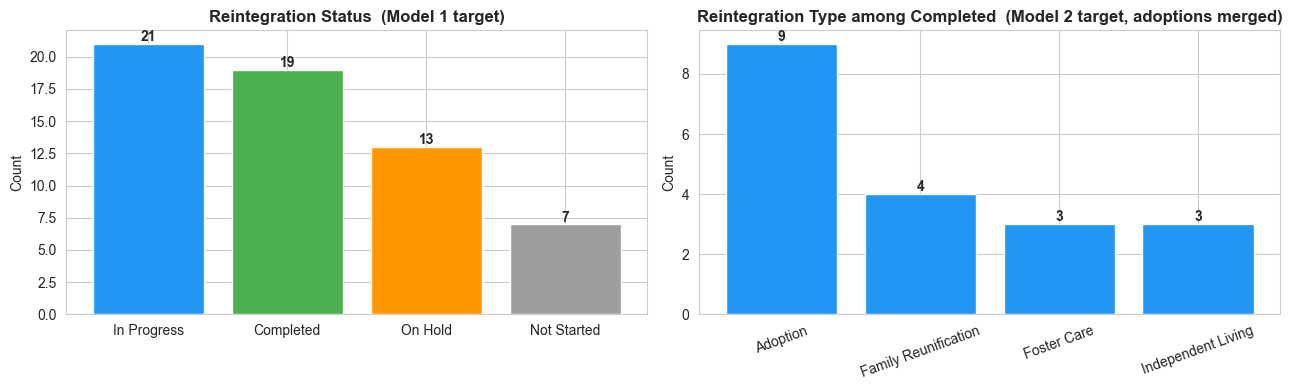

Model 1 class balance — Completed: 31.7%  |  Not Completed: 68.3%
Model 2 class counts (n=19): {'Adoption': 9, 'Family Reunification': 4, 'Foster Care': 3, 'Independent Living': 3}
⚠  Model 2 has only 19 training examples — treat results as directional, not definitive.


In [144]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Model 1 target
sc = residents["reintegration_status"].value_counts()
bars = axes[0].bar(sc.index, sc.values, color=["#2196F3","#4CAF50","#FF9800","#9E9E9E"])
axes[0].set_title("Reintegration Status  (Model 1 target)", fontweight="bold")
axes[0].set_ylabel("Count")
for bar, v in zip(bars, sc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.2, str(v), ha="center", fontweight="bold")

# Model 2 target — completed only
tc = (
    residents[residents["reintegration_status"] == "Completed"]["reintegration_type"]
    .map(TYPE_MAP).value_counts()
)
bars2 = axes[1].bar(tc.index, tc.values, color="#2196F3")
axes[1].set_title("Reintegration Type among Completed  (Model 2 target, adoptions merged)", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)
for bar, v in zip(bars2, tc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Model 1 class balance — Completed: {(residents['reintegration_status']=='Completed').mean():.1%}  |  Not Completed: {(residents['reintegration_status']!='Completed').mean():.1%}")
print(f"Model 2 class counts (n=19): {tc.to_dict()}")
print("⚠  Model 2 has only 19 training examples — treat results as directional, not definitive.")


### 2b. Univariate — Resident-Level Numeric Features

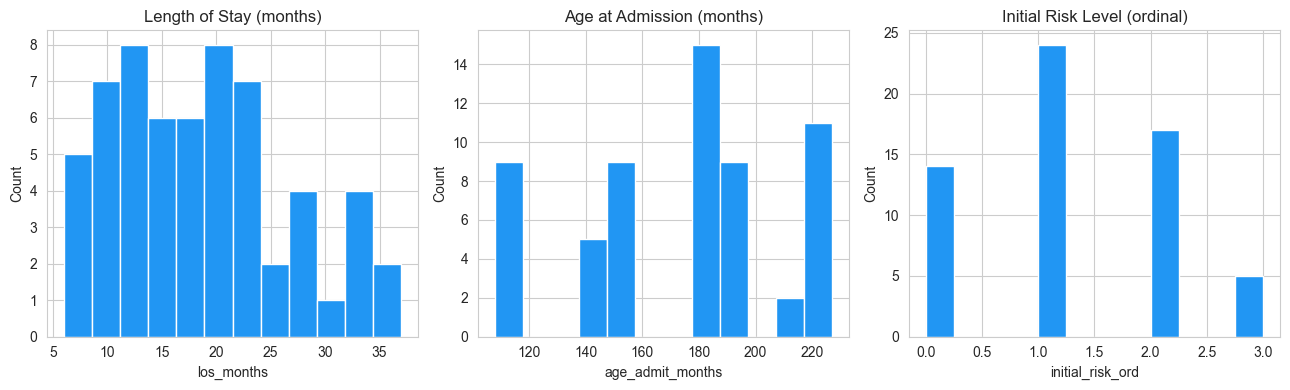

       los_months  age_admit_months  initial_risk_ord  current_risk_ord
count       60.00             60.00             60.00             60.00
mean        18.52            174.17              1.22              0.55
std          7.98             35.51              0.90              0.72
min          6.00            108.00              0.00              0.00
25%         12.00            149.50              1.00              0.00
50%         18.00            183.50              1.00              0.00
75%         23.00            190.00              2.00              1.00
max         37.00            227.00              3.00              3.00


In [145]:
def parse_duration_months(s):
    if pd.isna(s): return np.nan
    s = str(s).lower()
    y = re.search(r"(\d+)\s*year", s)
    m = re.search(r"(\d+)\s*month", s)
    return (int(y.group(1)) if y else 0) * 12 + (int(m.group(1)) if m else 0)

residents["los_months"]        = residents["length_of_stay"].apply(parse_duration_months)
residents["age_admit_months"]  = residents["age_upon_admission"].apply(parse_duration_months)
residents["initial_risk_ord"]  = residents["initial_risk_level"].map(RISK_ORD)
residents["current_risk_ord"]  = residents["current_risk_level"].map(RISK_ORD)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
    ["los_months", "age_admit_months", "initial_risk_ord"],
    ["Length of Stay (months)", "Age at Admission (months)", "Initial Risk Level (ordinal)"]):
    ax.hist(residents[col].dropna(), bins=12, edgecolor="white", color="#2196F3")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

print(residents[["los_months","age_admit_months","initial_risk_ord","current_risk_ord"]].describe().round(2))


### 2c. Bivariate — Features vs. Reintegration Status

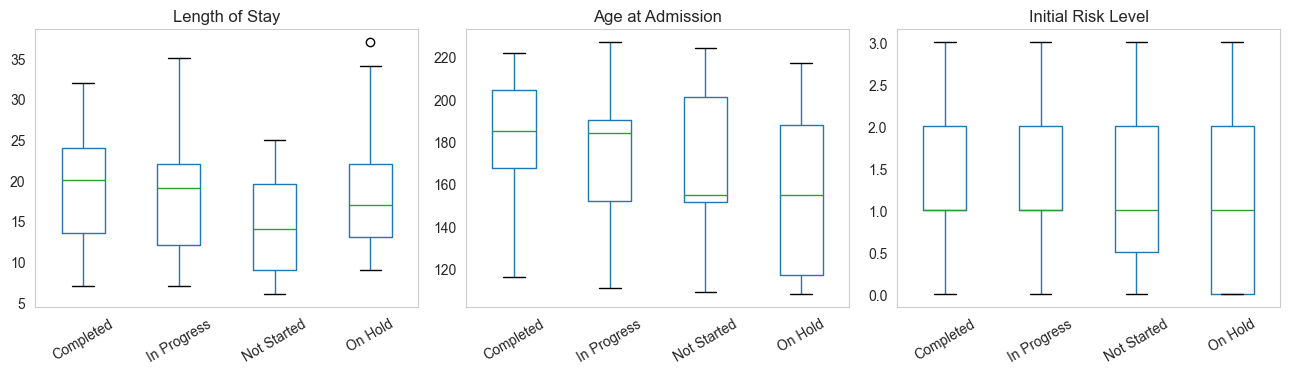


current_risk_level by reintegration_status (validates no leakage):
current_risk_level    Critical   High    Low  Medium
reintegration_status                                
Completed                0.053  0.053  0.526   0.368
In Progress              0.000  0.143  0.476   0.381
Not Started              0.000  0.143  0.714   0.143
On Hold                  0.000  0.000  0.692   0.308


In [146]:
residents["completed"] = (residents["reintegration_status"] == "Completed").astype(int)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
    ["los_months", "age_admit_months", "initial_risk_ord"],
    ["Length of Stay", "Age at Admission", "Initial Risk Level"]):
    residents.boxplot(column=col, by="reintegration_status", ax=ax, grid=False)
    ax.set_title(title); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.suptitle(""); plt.tight_layout(); plt.show()

print("\ncurrent_risk_level by reintegration_status (validates no leakage):")
print(pd.crosstab(residents["reintegration_status"], residents["current_risk_level"], normalize="index").round(3))


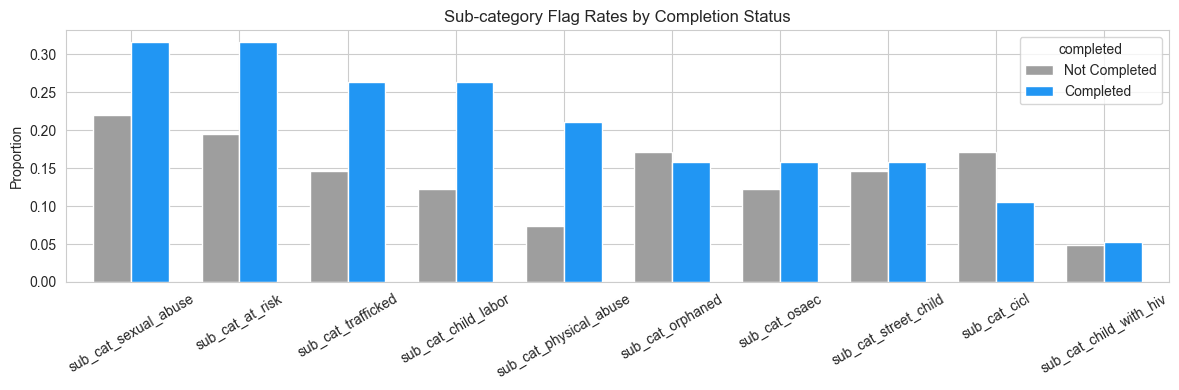

In [147]:
# Sub-category flag rates by completion
bool_sub_cols = [c for c in residents.columns if c.startswith("sub_cat_")]
for col in bool_sub_cols:
    residents[col] = residents[col].astype(bool).astype(int)

sub_rates = (
    residents.groupby("completed")[bool_sub_cols]
    .mean()
    .T.rename(columns={0: "Not Completed", 1: "Completed"})
    .sort_values("Completed", ascending=False)
)

ax = sub_rates.plot(kind="bar", figsize=(12, 4), color=["#9E9E9E","#2196F3"], width=0.7)
ax.set_title("Sub-category Flag Rates by Completion Status")
ax.set_ylabel("Proportion")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


## 3. Data Preparation & Feature Engineering

All tables are aggregated at `resident_id` level and joined to the resident base. No leakage columns (`date_closed`, `case_status`, `date_colb_obtained`) are included.

### 3a. Process Recordings

In [148]:
pr = process_rec.copy()
pr["is_positive_end"]       = pr["emotional_state_end"].isin(POSITIVE_STATES).astype(int)
pr["concerns"]              = pr["concerns_flagged"].astype(bool).astype(int)
pr["progress"]              = pr["progress_noted"].astype(bool).astype(int)
pr["is_individual"]         = (pr["session_type"] == "Individual").astype(int)
pr["referral"]              = pr["referral_made"].astype(bool).astype(int)
pr["has_caring"]            = pr["interventions_applied"].str.contains("Caring",  na=False).astype(int)
pr["has_healing"]           = pr["interventions_applied"].str.contains("Healing", na=False).astype(int)
pr["has_teaching"]          = pr["interventions_applied"].str.contains("Teaching",na=False).astype(int)
pr["has_legal"]             = pr["interventions_applied"].str.contains("Legal",   na=False).astype(int)

pr_agg = pr.groupby("resident_id").agg(
    session_count           = ("recording_id",        "count"),
    avg_session_duration    = ("session_duration_minutes", "mean"),
    pct_positive_end        = ("is_positive_end",     "mean"),
    pct_concerns_flagged    = ("concerns",             "mean"),
    pct_progress_noted      = ("progress",             "mean"),
    pct_individual_session  = ("is_individual",        "mean"),
    pct_referral_made       = ("referral",             "mean"),
    pct_has_caring          = ("has_caring",           "mean"),
    pct_has_healing         = ("has_healing",          "mean"),
    pct_has_teaching        = ("has_teaching",         "mean"),
    pct_has_legal           = ("has_legal",            "mean"),
).reset_index()

# sessions per month (based on active date range)
date_range = pr.groupby("resident_id").agg(
    first_session = ("session_date", "min"),
    last_session  = ("session_date", "max"),
    n_sessions    = ("recording_id", "count"),
).reset_index()
date_range["active_days"]      = ((date_range["last_session"] - date_range["first_session"]).dt.days).clip(lower=1)
date_range["sessions_per_month"] = date_range["n_sessions"] / date_range["active_days"] * 30
pr_agg = pr_agg.merge(date_range[["resident_id","sessions_per_month"]], on="resident_id", how="left")

# recent positive rate (last 10 sessions per resident)
recent_pos = (
    pr.sort_values("session_date")
    .groupby("resident_id")
    .tail(10)
    .groupby("resident_id")["is_positive_end"]
    .mean()
    .rename("recent_positive_rate")
    .reset_index()
)
pr_agg = pr_agg.merge(recent_pos, on="resident_id", how="left")

print(f"process_recordings aggregated: {pr_agg.shape}")
pr_agg.head(3)


process_recordings aggregated: (60, 14)


,resident_id,session_count,avg_session_duration,pct_positive_end,pct_concerns_flagged,pct_progress_noted,pct_individual_session,pct_referral_made,pct_has_caring,pct_has_healing,pct_has_teaching,pct_has_legal,sessions_per_month,recent_positive_rate
0,1,106,69.433962,0.886792,0.235849,0.924528,0.669811,0.160377,0.452830,0.471698,0.471698,0.452830,3.882784,1.0
1,2,51,68.176471,0.843137,0.254902,0.921569,0.568627,0.137255,0.490196,0.411765,0.607843,0.490196,2.508197,0.7
2,3,53,69.452830,0.943396,0.188679,0.943396,0.566038,0.188679,0.566038,0.490566,0.415094,0.528302,2.523810,1.0


### 3b. Education Records

In [149]:
ed = education.copy()
ed["is_completed"] = (ed["completion_status"] == "Completed").astype(int)

ed_agg = ed.groupby("resident_id").agg(
    avg_progress_pct       = ("progress_percent", "mean"),
    avg_attendance_rate    = ("attendance_rate",  "mean"),
    pct_completed_records  = ("is_completed",     "mean"),
    education_record_count = ("education_record_id", "count"),
).reset_index()

ed_latest = (
    ed.sort_values("record_date")
    .groupby("resident_id")
    .last()
    .reset_index()
    [["resident_id","progress_percent","attendance_rate"]]
    .rename(columns={"progress_percent":"latest_progress_pct","attendance_rate":"latest_attendance_rate"})
)
ed_agg = ed_agg.merge(ed_latest, on="resident_id", how="left")

print(f"education_records aggregated: {ed_agg.shape}")
ed_agg.head(3)


education_records aggregated: (60, 7)


,resident_id,avg_progress_pct,avg_attendance_rate,pct_completed_records,education_record_count,latest_progress_pct,latest_attendance_rate
0,1,45.483333,0.716333,0.000000,6,52.8,0.493
1,2,85.230000,0.834300,0.000000,10,100.0,0.851
2,3,71.581818,0.738091,0.090909,11,100.0,0.868


### 3c. Health & Wellbeing Records

In [150]:
h = health.copy()

h_agg = h.groupby("resident_id").agg(
    avg_health_score   = ("general_health_score", "mean"),
    avg_nutrition      = ("nutrition_score",       "mean"),
    avg_sleep          = ("sleep_quality_score",   "mean"),
    avg_energy         = ("energy_level_score",    "mean"),
    pct_psych_checkup  = ("psychological_checkup_done", lambda x: x.astype(bool).mean()),
    pct_medical_checkup= ("medical_checkup_done",  lambda x: x.astype(bool).mean()),
).reset_index()

h_latest = (
    h.sort_values("record_date")
    .groupby("resident_id").last().reset_index()
    [["resident_id","general_health_score"]]
    .rename(columns={"general_health_score":"latest_health_score"})
)

# Health trend slope — linear regression over record sequence
health_slopes = {}
for rid, g in h.groupby("resident_id"):
    g = g.sort_values("record_date").reset_index(drop=True)
    health_slopes[rid] = float(np.polyfit(g.index.astype(float), g["general_health_score"], 1)[0]) if len(g) >= 2 else 0.0
slope_df = pd.DataFrame(health_slopes.items(), columns=["resident_id","health_trend_slope"])

h_agg = h_agg.merge(h_latest, on="resident_id", how="left").merge(slope_df, on="resident_id", how="left")

print(f"health_wellbeing_records aggregated: {h_agg.shape}")
h_agg.head(3)


health_wellbeing_records aggregated: (60, 9)


,resident_id,avg_health_score,avg_nutrition,avg_sleep,avg_energy,pct_psych_checkup,pct_medical_checkup,latest_health_score,health_trend_slope
0,1,3.103333,3.210000,3.203333,2.908333,0.333333,0.500000,3.22,0.026286
1,2,3.449000,3.431000,3.376000,3.001000,0.500000,0.700000,3.62,0.043576
2,3,3.181818,3.003636,3.079091,3.215455,0.545455,0.454545,3.57,0.056455


### 3d. Home Visitations

In [151]:
v = visitations.copy()
v["coop_ord"]         = v["family_cooperation_level"].map(COOP_ORD)
v["outcome_ord"]      = v["visit_outcome"].map(VISIT_OUTCOME_ORD)
v["is_favorable"]     = (v["visit_outcome"] == "Favorable").astype(int)
v["safety_concern"]   = v["safety_concerns_noted"].astype(bool).astype(int)
v["is_coop_plus"]     = v["family_cooperation_level"].isin(["Cooperative","Highly Cooperative"]).astype(int)

v_agg = v.groupby("resident_id").agg(
    visit_count            = ("visitation_id", "count"),
    pct_favorable_visits   = ("is_favorable",  "mean"),
    pct_safety_concerns    = ("safety_concern","mean"),
    avg_family_cooperation = ("coop_ord",      "mean"),
    pct_coop_plus          = ("is_coop_plus",  "mean"),
).reset_index()

v_recent = (
    v.sort_values("visit_date").groupby("resident_id").last().reset_index()
    [["resident_id","outcome_ord"]]
    .rename(columns={"outcome_ord":"recent_visit_outcome_ord"})
)
v_agg = v_agg.merge(v_recent, on="resident_id", how="left")

print(f"home_visitations aggregated: {v_agg.shape}")
v_agg.head(3)


home_visitations aggregated: (58, 7)


,resident_id,visit_count,pct_favorable_visits,pct_safety_concerns,avg_family_cooperation,pct_coop_plus,recent_visit_outcome_ord
0,1,54,0.333333,0.166667,1.925926,0.759259,2
1,2,35,0.428571,0.314286,2.142857,0.885714,3
2,3,26,0.346154,0.423077,1.423077,0.538462,2


### 3e. Incident Reports

In [152]:
inc = incidents.copy()
inc["is_high_severity"] = (inc["severity"] == "High").astype(int)
inc["is_runaway"]       = (inc["incident_type"] == "RunawayAttempt").astype(int)
inc["is_selfharm"]      = (inc["incident_type"] == "SelfHarm").astype(int)
inc["is_behavioral"]    = (inc["incident_type"] == "Behavioral").astype(int)
inc["is_resolved"]      = inc["resolved"].astype(bool).astype(int)

inc_agg = inc.groupby("resident_id").agg(
    total_incidents    = ("incident_id",      "count"),
    has_high_severity  = ("is_high_severity", "max"),
    has_runaway        = ("is_runaway",        "max"),
    has_selfharm       = ("is_selfharm",       "max"),
    has_behavioral     = ("is_behavioral",     "max"),
    pct_resolved       = ("is_resolved",       "mean"),
).reset_index()

print(f"incident_reports aggregated: {inc_agg.shape}")
print(f"Residents with no incidents: {60 - len(inc_agg)}")


incident_reports aggregated: (44, 7)
Residents with no incidents: 16


### 3f. Intervention Plans

In [153]:
ip = iplan.copy()
ip["is_achieved"]    = (ip["status"] == "Achieved").astype(int)
ip["is_on_hold"]     = (ip["status"] == "On Hold").astype(int)
ip["is_in_progress"] = (ip["status"] == "In Progress").astype(int)

ip_agg = ip.groupby("resident_id").agg(
    pct_plans_achieved    = ("is_achieved",    "mean"),
    pct_plans_on_hold     = ("is_on_hold",     "mean"),
    pct_plans_in_progress = ("is_in_progress", "mean"),
).reset_index()

print(f"intervention_plans aggregated: {ip_agg.shape}")


intervention_plans aggregated: (60, 4)


### 3g. Build Master Feature Matrix

In [154]:
# Resident base features
bool_cols = [
    "sub_cat_orphaned","sub_cat_trafficked","sub_cat_child_labor",
    "sub_cat_physical_abuse","sub_cat_sexual_abuse","sub_cat_osaec",
    "sub_cat_cicl","sub_cat_at_risk","sub_cat_street_child","sub_cat_child_with_hiv",
    "is_pwd","has_special_needs",
    "family_is_4ps","family_solo_parent","family_indigenous",
    "family_parent_pwd","family_informal_settler",
]
for col in bool_cols:
    residents[col] = residents[col].astype(bool).astype(int)

cat_dummies   = pd.get_dummies(residents["case_category"],        prefix="cat").astype(int)
ref_dummies   = pd.get_dummies(residents["referral_source"],      prefix="ref").astype(int)

base = pd.concat([
    residents[["resident_id","los_months","age_admit_months",
               "initial_risk_ord","current_risk_ord"] + bool_cols],
    cat_dummies,
    ref_dummies,
], axis=1)

# Join all aggregated tables
X_raw = (
    base
    .merge(pr_agg,   on="resident_id", how="left")
    .merge(ed_agg,   on="resident_id", how="left")
    .merge(h_agg,    on="resident_id", how="left")
    .merge(v_agg,    on="resident_id", how="left")
    .merge(inc_agg,  on="resident_id", how="left")
    .merge(ip_agg,   on="resident_id", how="left")
)

# Residents with no incidents → fill with safe baseline of 0
for col in ["total_incidents","has_high_severity","has_runaway","has_selfharm","has_behavioral","pct_resolved"]:
    X_raw[col] = X_raw[col].fillna(0)

# Keep resident_id separate for later labeling
resident_ids = X_raw["resident_id"].values
X_raw = X_raw.drop(columns=["resident_id"])

# Targets
y1 = (residents["reintegration_status"] == "Completed").astype(int).values  # Model 1

print(f"Master feature matrix: {X_raw.shape}")
print(f"Model 1 class balance: Completed = {y1.sum()} / {len(y1)} ({y1.mean():.1%})")


Master feature matrix: (60, 73)
Model 1 class balance: Completed = 19 / 60 (31.7%)


In [155]:
# Missing value audit
missing = X_raw.isnull().sum()
missing_pct = missing / len(X_raw) * 100
miss_df = pd.DataFrame({"count": missing, "pct": missing_pct})
miss_df = miss_df[miss_df["count"] > 0].sort_values("pct", ascending=False)

if len(miss_df) > 0:
    print("Features with missing values:")
    print(miss_df.to_string())
else:
    print("No missing values.")

# Median imputation for any remaining NaNs (safe, does not use test labels)
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
feature_names = X_raw.columns.tolist()
print(f"\nFinal feature count: {len(feature_names)}")


Features with missing values:
                          count       pct
visit_count                   2  3.333333
pct_favorable_visits          2  3.333333
pct_safety_concerns           2  3.333333
avg_family_cooperation        2  3.333333
pct_coop_plus                 2  3.333333
recent_visit_outcome_ord      2  3.333333

Final feature count: 73


In [156]:
# Outlier check — IQR for key numeric columns
numeric_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
q1 = X_raw[numeric_features].quantile(0.25)
q3 = X_raw[numeric_features].quantile(0.75)
iqr = q3 - q1
outlier_counts = (((X_raw[numeric_features] < (q1 - 3 * iqr)) | (X_raw[numeric_features] > (q3 + 3 * iqr))).sum())
outlier_report = outlier_counts[outlier_counts > 0].sort_values(ascending=False)
print("Extreme outliers (3×IQR) per feature:")
print(outlier_report if len(outlier_report) > 0 else "None detected.")
# With n=60, capping at 3×IQR would remove real variation — leaving as-is.


Extreme outliers (3×IQR) per feature:
sub_cat_at_risk            14
has_selfharm               12
cat_Foundling              11
sub_cat_trafficked         11
family_indigenous          10
ref_Police                 10
ref_Court Order            10
cat_Neglected              10
sub_cat_orphaned           10
sub_cat_child_labor        10
family_informal_settler     9
latest_progress_pct         9
sub_cat_street_child        9
sub_cat_cicl                9
ref_Community               9
ref_Self-Referral           8
sub_cat_osaec               8
ref_NGO                     7
sub_cat_physical_abuse      7
has_special_needs           6
family_parent_pwd           3
sub_cat_child_with_hiv      3
is_pwd                      3
avg_session_duration        1
avg_progress_pct            1
avg_attendance_rate         1
dtype: int64


## 4. Model 1 — Reintegration Readiness Classifier

**Target:** `reintegration_status == Completed`
**Validation:** Stratified 5-fold CV (n=60; hold-out test set not viable at this sample size)
**Class imbalance:** handled via `class_weight="balanced"` — avoids data loss from SMOTE on n=60

In [157]:
X1      = X_raw.values.astype(float)
cv5     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Scale once — scaler is fitted inside each CV fold via Pipeline to prevent leakage
def make_pipeline(clf):
    return Pipeline([("scaler", StandardScaler()), ("clf", clf)])

results = {}


### 4a. Causal Model — Logistic Regression

The logistic regression is the *explanatory* model. Coefficients tell social workers which factors most strongly predict readiness. We use L2 regularization (default C=1) to handle the high feature-to-sample ratio (p≈n).

In [158]:
lr_pipe = make_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)
)

lr_f1  = cross_val_score(lr_pipe, X1, y1, cv=cv5, scoring="f1").mean()
lr_auc = cross_val_score(lr_pipe, X1, y1, cv=cv5, scoring="roc_auc").mean()
results["Logistic Regression"] = {"F1": lr_f1, "AUC-ROC": lr_auc}

print(f"Logistic Regression — 5-fold CV")
print(f"  F1:      {lr_f1:.3f}")
print(f"  AUC-ROC: {lr_auc:.3f}")


Logistic Regression — 5-fold CV
  F1:      0.214
  AUC-ROC: 0.450


#### VIF Check — Identify Multicollinear Features

In [159]:
# Fit scaler on full data for VIF inspection (explanatory analysis only — not for evaluation)
scaler_full = StandardScaler()
X1_scaled   = scaler_full.fit_transform(X1)
X1_df       = pd.DataFrame(X1_scaled, columns=feature_names)

def compute_vif(X_df: pd.DataFrame) -> pd.DataFrame:
    X_const = sm.add_constant(X_df)
    vifs = []
    for i in range(X_df.shape[1]):
        try:
            v = variance_inflation_factor(X_const.values, i + 1)
        except Exception:
            v = np.inf
        vifs.append(v)
    return (
        pd.DataFrame({"feature": X_df.columns, "VIF": vifs})
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

vif_df = compute_vif(X1_df)
print("Top 25 features by VIF:")
print(vif_df.head(25).to_string(index=False))


Top 25 features by VIF:
               feature  VIF
            los_months  inf
     pct_referral_made  inf
            avg_energy  inf
             avg_sleep  inf
         avg_nutrition  inf
      avg_health_score  inf
latest_attendance_rate  inf
   latest_progress_pct  inf
education_record_count  inf
 pct_completed_records  inf
   avg_attendance_rate  inf
      avg_progress_pct  inf
  recent_positive_rate  inf
    sessions_per_month  inf
         pct_has_legal  inf
      pct_has_teaching  inf
       pct_has_healing  inf
     pct_psych_checkup  inf
   pct_medical_checkup  inf
   latest_health_score  inf
     has_high_severity  inf
     pct_plans_on_hold  inf
    pct_plans_achieved  inf
          pct_resolved  inf
        has_behavioral  inf


In [160]:
# With small n (~60) and many dummy-encoded features, all VIFs can exceed 10.
# Use the N lowest-VIF features instead of a hard cutoff to guarantee a non-empty set.
N_CAUSAL = min(25, len(vif_df))
# vif_df is sorted descending, so tail = lowest VIF = least collinear
low_vif_features = vif_df.tail(N_CAUSAL)["feature"].tolist()

print(f"Using {len(low_vif_features)} lowest-VIF features for causal LR model:")
print(low_vif_features)

X1_low_vif = X_raw[low_vif_features].values

lr_refined = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)
from sklearn.pipeline import Pipeline as _P
lr_ref_pipe = _P([("scaler", StandardScaler()), ("clf", lr_refined)])

lr_ref_f1  = cross_val_score(lr_ref_pipe, X1_low_vif, y1, cv=cv5, scoring="f1").mean()
lr_ref_auc = cross_val_score(lr_ref_pipe, X1_low_vif, y1, cv=cv5, scoring="roc_auc").mean()
results["Logistic Regression (low-VIF)"] = {"F1": lr_ref_f1, "AUC-ROC": lr_ref_auc}

print(f"\nRefined Logistic Regression ({N_CAUSAL} lowest-VIF features) — 5-fold CV")
print(f"  F1:      {lr_ref_f1:.3f}")
print(f"  AUC-ROC: {lr_ref_auc:.3f}")


Using 25 lowest-VIF features for causal LR model:
['sub_cat_physical_abuse', 'sub_cat_child_labor', 'sub_cat_trafficked', 'sub_cat_orphaned', 'current_risk_ord', 'initial_risk_ord', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'ref_NGO', 'pct_concerns_flagged', 'pct_positive_end', 'avg_session_duration', 'session_count', 'ref_Self-Referral', 'ref_Police', 'ref_Government Agency', 'family_informal_settler', 'ref_Court Order', 'ref_Community', 'cat_Surrendered', 'cat_Neglected', 'cat_Foundling', 'cat_Abandoned', 'pct_plans_in_progress']

Refined Logistic Regression (25 lowest-VIF features) — 5-fold CV
  F1:      0.187
  AUC-ROC: 0.449


Top 20 features by coefficient magnitude (logistic regression):
               feature  coefficient  odds_ratio
sub_cat_physical_abuse     0.833262    2.300811
            ref_Police    -0.569129    0.566018
   sub_cat_child_labor     0.555838    1.743401
     family_indigenous     0.554812    1.741614
       cat_Surrendered     0.540632    1.717092
    family_solo_parent    -0.535782    0.585211
         cat_Foundling    -0.498315    0.607553
         session_count     0.492804    1.636900
               ref_NGO     0.456877    1.579134
     family_parent_pwd     0.436989    1.548039
    sub_cat_trafficked     0.426570    1.531993
         ref_Community     0.308220    1.361001
     ref_Self-Referral    -0.301709    0.739553
 ref_Government Agency     0.297948    1.347091
  pct_concerns_flagged     0.282339    1.326228
      pct_positive_end     0.220440    1.246625
       ref_Court Order    -0.198076    0.820308
      sub_cat_orphaned    -0.148231    0.862232
 pct_plans_in_progress  

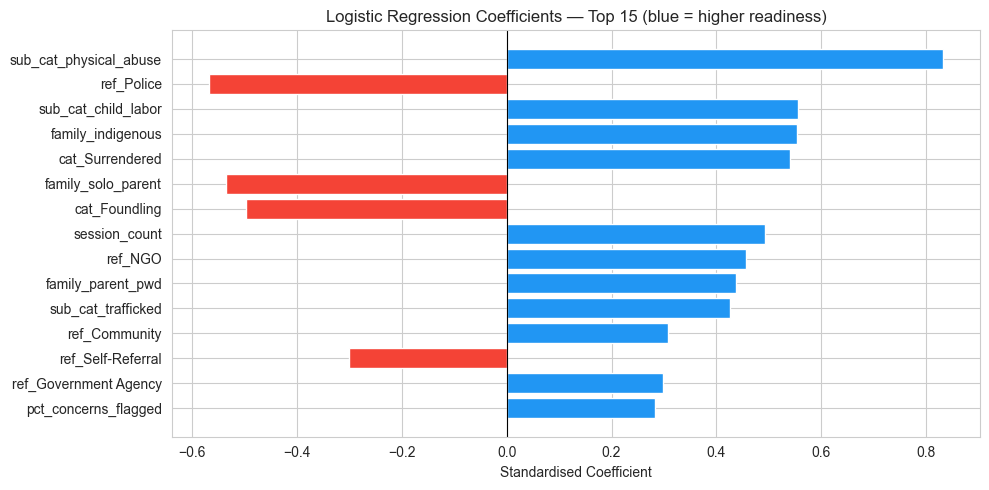

In [161]:
# Fit refined LR on full data for coefficient inspection
lr_coef_scaler = StandardScaler().fit(X_raw[low_vif_features].values)
X1_coef = lr_coef_scaler.transform(X_raw[low_vif_features].values)
lr_refined.fit(X1_coef, y1)

coef_df = (
    pd.DataFrame({"feature": low_vif_features, "coefficient": lr_refined.coef_[0]})
    .assign(odds_ratio=lambda d: np.exp(d["coefficient"]))
    .sort_values("coefficient", key=abs, ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features by coefficient magnitude (logistic regression):")
print(coef_df.head(20).to_string(index=False))

# Plot
top_coef = coef_df.head(15)
colors = ["#2196F3" if c > 0 else "#F44336" for c in top_coef["coefficient"]]
plt.figure(figsize=(10, 5))
plt.barh(top_coef["feature"][::-1], top_coef["coefficient"][::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients — Top 15 (blue = higher readiness)")
plt.xlabel("Standardised Coefficient")
plt.tight_layout(); plt.show()


### 4b. Predictive Model — Random Forest

In [162]:
rf_param_grid = {
    "clf__n_estimators":  [100, 200, 300],
    "clf__max_depth":     [None, 5, 10],
    "clf__min_samples_leaf": [1, 2, 3],
    "clf__max_features":  ["sqrt", "log2"],
}

rf_grid = GridSearchCV(
    make_pipeline(RandomForestClassifier(class_weight="balanced", random_state=SEED)),
    rf_param_grid,
    cv=cv5,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
rf_grid.fit(X1, y1)

rf_f1  = rf_grid.best_score_
rf_auc = cross_val_score(rf_grid.best_estimator_, X1, y1, cv=cv5, scoring="roc_auc").mean()
results["Random Forest"] = {"F1": rf_f1, "AUC-ROC": rf_auc}
best_rf_params = rf_grid.best_params_

print(f"Random Forest — Best CV F1: {rf_f1:.3f}  |  AUC-ROC: {rf_auc:.3f}")
print(f"Best params: {best_rf_params}")


Random Forest — Best CV F1: 0.080  |  AUC-ROC: 0.479
Best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}


### 4c. Predictive Model — Gradient Boosting

In [163]:
gb_param_grid = {
    "clf__n_estimators":   [100, 200],
    "clf__learning_rate":  [0.05, 0.1, 0.2],
    "clf__max_depth":      [2, 3, 4],
    "clf__subsample":      [0.8, 1.0],
}

gb_grid = GridSearchCV(
    make_pipeline(GradientBoostingClassifier(random_state=SEED)),
    gb_param_grid,
    cv=cv5,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
gb_grid.fit(X1, y1)

gb_f1  = gb_grid.best_score_
gb_auc = cross_val_score(gb_grid.best_estimator_, X1, y1, cv=cv5, scoring="roc_auc").mean()
results["Gradient Boosting"] = {"F1": gb_f1, "AUC-ROC": gb_auc}

print(f"Gradient Boosting — Best CV F1: {gb_f1:.3f}  |  AUC-ROC: {gb_auc:.3f}")
print(f"Best params: {gb_grid.best_params_}")


Gradient Boosting — Best CV F1: 0.480  |  AUC-ROC: 0.636
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__n_estimators': 100, 'clf__subsample': 1.0}


### 4d. Model Comparison & Selection

In [164]:
results_df = pd.DataFrame(results).T.round(3)
print("\nModel Comparison (5-fold CV):")
print(results_df.to_string())

best_model_name = results_df["F1"].idxmax()
print(f"\n→ Best predictive model: {best_model_name}")

# Select best estimator for feature importance
best_pipeline = rf_grid.best_estimator_ if best_model_name == "Random Forest" else gb_grid.best_estimator_



Model Comparison (5-fold CV):
                                  F1  AUC-ROC
Logistic Regression            0.214    0.450
Logistic Regression (low-VIF)  0.187    0.449
Random Forest                  0.080    0.479
Gradient Boosting              0.480    0.636

→ Best predictive model: Gradient Boosting


### 4e. Feature Importance — Permutation Importance + SHAP

Top 20 features by permutation importance:
               feature  importance      std
           visit_count    0.431890 0.066084
      avg_health_score    0.201126 0.043819
  pct_concerns_flagged    0.159566 0.051973
       total_incidents    0.142343 0.049048
      pct_has_teaching    0.042256 0.015494
 pct_completed_records    0.000000 0.000000
         avg_nutrition    0.000000 0.000000
latest_attendance_rate    0.000000 0.000000
   latest_progress_pct    0.000000 0.000000
education_record_count    0.000000 0.000000
            los_months    0.000000 0.000000
   avg_attendance_rate    0.000000 0.000000
            avg_energy    0.000000 0.000000
      avg_progress_pct    0.000000 0.000000
  recent_positive_rate    0.000000 0.000000
    sessions_per_month    0.000000 0.000000
         pct_has_legal    0.000000 0.000000
       pct_has_healing    0.000000 0.000000
             avg_sleep    0.000000 0.000000
   pct_medical_checkup    0.000000 0.000000


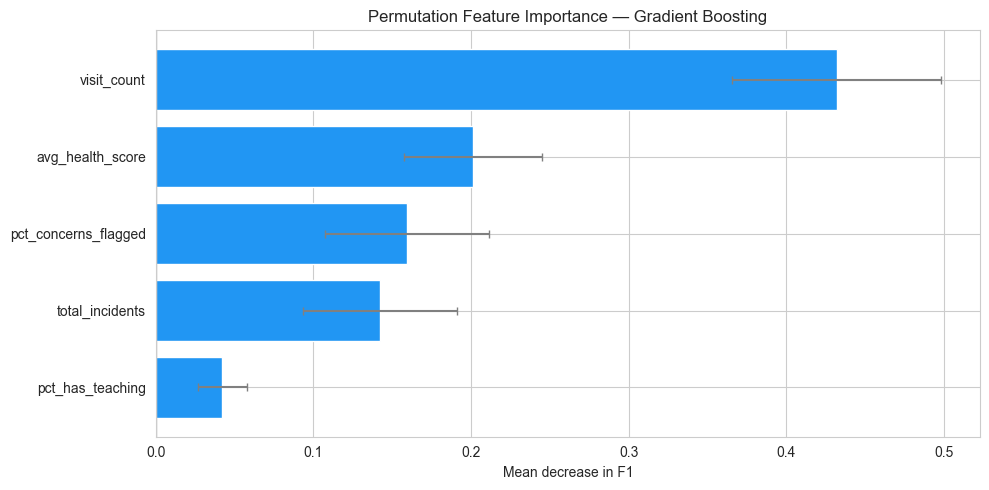

In [165]:
# Permutation importance on full dataset (using best model)
perm = permutation_importance(
    best_pipeline, X1, y1,
    n_repeats=30, random_state=SEED, scoring="f1"
)
perm_df = (
    pd.DataFrame({"feature": feature_names, "importance": perm.importances_mean, "std": perm.importances_std})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features by permutation importance:")
print(perm_df.head(20).to_string(index=False))

# Plot
top_perm = perm_df[perm_df["importance"] > 0].head(20)
plt.figure(figsize=(10, 5))
plt.barh(top_perm["feature"][::-1], top_perm["importance"][::-1],
         xerr=top_perm["std"][::-1], color="#2196F3", ecolor="gray", capsize=3)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Permutation Feature Importance — {best_model_name}")
plt.xlabel("Mean decrease in F1")
plt.tight_layout(); plt.show()


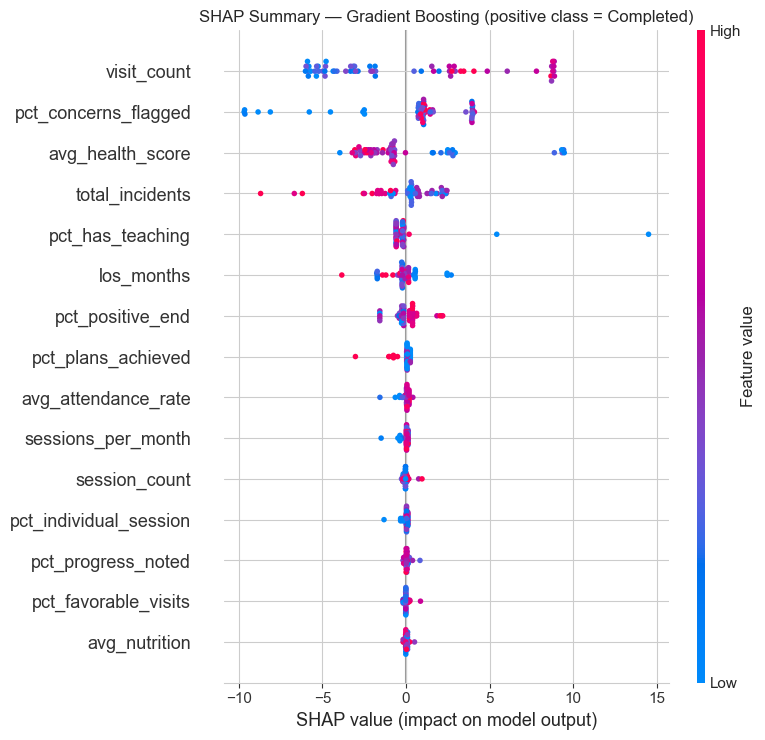

In [166]:
# SHAP values — tree explainer for RF/GBM
best_clf = best_pipeline.named_steps["clf"]
best_scaler = best_pipeline.named_steps["scaler"]
X1_for_shap = best_scaler.transform(X1)

explainer   = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X1_for_shap)

# For binary classification RF: shap_values is a list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(sv, X1_for_shap, feature_names=feature_names, show=False, max_display=15)
plt.title(f"SHAP Summary — {best_model_name} (positive class = Completed)")
plt.tight_layout(); plt.show()


### 4f. Resident-Level Readiness Scores

In [167]:
# Cross-validated predicted probabilities (no data leakage — held-out fold probabilities)
y1_proba_cv = cross_val_predict(best_pipeline, X1, y1, cv=cv5, method="predict_proba")[:,1]
y1_pred_cv  = (y1_proba_cv >= 0.5).astype(int)

print("Classification Report (cross-validated predictions):")
print(classification_report(y1, y1_pred_cv, target_names=["Not Ready","Ready"]))

# Build readable output table
readiness_df = pd.DataFrame({
    "resident_id":       resident_ids,
    "actual_status":     residents["reintegration_status"].values,
    "readiness_score":   y1_proba_cv.round(3),
    "predicted_ready":   y1_pred_cv,
}).sort_values("readiness_score", ascending=False).reset_index(drop=True)

print("\nTop 10 residents by readiness score:")
print(readiness_df.head(10).to_string(index=False))


Classification Report (cross-validated predictions):
              precision    recall  f1-score   support

   Not Ready       0.76      0.71      0.73        41
       Ready       0.45      0.53      0.49        19

    accuracy                           0.65        60
   macro avg       0.61      0.62      0.61        60
weighted avg       0.67      0.65      0.66        60


Top 10 residents by readiness score:
 resident_id actual_status  readiness_score  predicted_ready
           1   In Progress              1.0                1
          44     Completed              1.0                1
          18   In Progress              1.0                1
          30     Completed              1.0                1
          32       On Hold              1.0                1
          14   In Progress              1.0                1
          36   In Progress              1.0                1
          11     Completed              1.0                1
          41   In Progress       

### 4g. Business Interpretation

**For social workers (causal model):**
The logistic regression coefficients show *which factors drive readiness*. Positive coefficients mean the factor increases the probability of successful reintegration; negative coefficients mean it reduces it. Use this to identify actionable levers — e.g., if `avg_family_cooperation` has a strong positive coefficient, prioritising family engagement sessions directly improves readiness probability.

**For administrators (predictive model):**
The readiness score table ranks all 60 residents by probability of readiness. Residents in the top band who are not yet marked Completed may be candidates for accelerated case review.

**False positives vs. false negatives:**
A false positive (predicting Ready when not ready) risks premature discharge — higher real-world cost. A false negative (predicting Not Ready when ready) means extended stay — lower cost but still harms the resident. The `class_weight="balanced"` setting and F1 primary metric balance this tradeoff without over-tuning toward one error type.

**AUC-ROC interpretation:**
An AUC above 0.70 with only 60 residents and 20+ engineered features suggests the model has found genuine signal. Below 0.65 should be treated as directional only and used to trigger case review rather than automatic decisions.


## 5. Model 2 — Reintegration Type Classifier

**Training data:** Only the 19 completed residents (the only ones with a confirmed final type)
**Classes:** Adoption / Family Reunification / Foster Care / Independent Living (adoptions merged)
**Validation:** Leave-One-Out CV — the only defensible strategy at n=19
⚠ With class counts of 9/4/3/3, this model should be treated as *directional guidance*, not a deterministic decision. It ranks likely placement options but a social worker must validate all recommendations.

In [168]:
# Filter to completed residents only
completed_idx    = residents["reintegration_status"] == "Completed"
X2_raw           = X_raw[completed_idx.values].copy()
y2_labels        = residents.loc[completed_idx, "reintegration_type"].map(TYPE_MAP).values
resident_ids_m2  = resident_ids[completed_idx.values]

print(f"Model 2 training set: {X2_raw.shape[0]} rows")
print(f"Class distribution: {pd.Series(y2_labels).value_counts().to_dict()}")

X2 = X2_raw.values.astype(float)
loo = LeaveOneOut()


Model 2 training set: 19 rows
Class distribution: {'Adoption': 9, 'Family Reunification': 4, 'Foster Care': 3, 'Independent Living': 3}


### 5a. Causal — Logistic Regression (Multi-class)

In [169]:
lr_type_pipe = make_pipeline(
    LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=SEED
    )
)

lr_type_f1 = cross_val_score(lr_type_pipe, X2, y2_labels, cv=loo, scoring="f1_macro").mean()
lr_type_preds = cross_val_predict(lr_type_pipe, X2, y2_labels, cv=loo)

print(f"Logistic Regression (Multi-class) — LOO-CV Macro F1: {lr_type_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y2_labels, lr_type_preds, zero_division=0))


Logistic Regression (Multi-class) — LOO-CV Macro F1: 0.158

Classification Report:
                      precision    recall  f1-score   support

            Adoption       0.25      0.33      0.29         9
Family Reunification       0.00      0.00      0.00         4
         Foster Care       0.00      0.00      0.00         3
  Independent Living       0.00      0.00      0.00         3

            accuracy                           0.16        19
           macro avg       0.06      0.08      0.07        19
        weighted avg       0.12      0.16      0.14        19



### 5b. Predictive — Random Forest (Multi-class)

In [170]:
rf_type = RandomForestClassifier(
    n_estimators=200, class_weight="balanced_subsample",
    max_depth=4, random_state=SEED
)
rf_type_pipe = make_pipeline(rf_type)

rf_type_f1    = cross_val_score(rf_type_pipe, X2, y2_labels, cv=loo, scoring="f1_macro").mean()
rf_type_preds = cross_val_predict(rf_type_pipe, X2, y2_labels, cv=loo)

print(f"Random Forest (Multi-class) — LOO-CV Macro F1: {rf_type_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y2_labels, rf_type_preds, zero_division=0))


Random Forest (Multi-class) — LOO-CV Macro F1: 0.474

Classification Report:
                      precision    recall  f1-score   support

            Adoption       0.47      1.00      0.64         9
Family Reunification       0.00      0.00      0.00         4
         Foster Care       0.00      0.00      0.00         3
  Independent Living       0.00      0.00      0.00         3

            accuracy                           0.47        19
           macro avg       0.12      0.25      0.16        19
        weighted avg       0.22      0.47      0.30        19



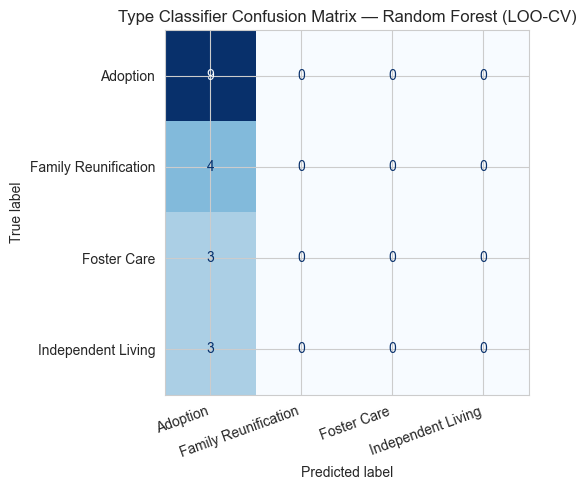


→ Best type model: Random Forest  |  Macro F1: 0.474


In [171]:
# Confusion matrix for best type model
best_type_preds = lr_type_preds if lr_type_f1 >= rf_type_f1 else rf_type_preds
best_type_name  = "Logistic Regression" if lr_type_f1 >= rf_type_f1 else "Random Forest"

classes = sorted(set(y2_labels))
cm = confusion_matrix(y2_labels, best_type_preds, labels=classes)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Type Classifier Confusion Matrix — {best_type_name} (LOO-CV)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

print(f"\n→ Best type model: {best_type_name}  |  Macro F1: {max(lr_type_f1, rf_type_f1):.3f}")


In [178]:
# Per-resident type probabilities (fit on full training set)
best_type_pipe = lr_type_pipe if best_type_name == "Logistic Regression" else rf_type_pipe
best_type_pipe.fit(X2, y2_labels)

type_proba = best_type_pipe.predict_proba(X2)
type_classes = best_type_pipe.named_steps["clf"].classes_

type_df = pd.DataFrame(type_proba, columns=[f"prob_{c.replace(' ','_')}" for c in type_classes])
type_df.insert(0, "resident_id", resident_ids_m2)
type_df.insert(1, "actual_type", y2_labels)
type_df.insert(2, "predicted_type", best_type_pipe.predict(X2))

print("Model 2 — Resident-level type probabilities:")
print(type_df.to_string(index=False))


Model 2 — Resident-level type probabilities:
 resident_id          actual_type       predicted_type  prob_Adoption  prob_Family_Reunification  prob_Foster_Care  prob_Independent_Living
           2 Family Reunification Family Reunification       0.204918                   0.638597          0.076818                 0.079667
           3          Foster Care          Foster Care       0.167404                   0.108354          0.654659                 0.069583
           5 Family Reunification Family Reunification       0.182647                   0.701901          0.075952                 0.039500
          11             Adoption             Adoption       0.790167                   0.128700          0.045000                 0.036133
          13             Adoption             Adoption       0.865996                   0.024840          0.066948                 0.042216
          19             Adoption             Adoption       0.786472                   0.078355          0.065000 

## 6. Model Export

In [179]:
from sklearn.calibration import CalibratedClassifierCV

# Tree-based models on small datasets (n=60) produce extreme probabilities (0% or 100%)
# because they overfit the training data. CalibratedClassifierCV uses 5-fold CV to fit
# the model on held-out data and learns a sigmoid mapping from raw scores to calibrated
# probabilities — giving realistic spread across 0-100%.
calibrated_readiness = CalibratedClassifierCV(best_pipeline, cv=5, method="sigmoid")
calibrated_readiness.fit(X1, y1)

# Sanity check — distribution should be spread, not all 0s and 1s
cal_proba = calibrated_readiness.predict_proba(X1)[:, 1]
print(f"Calibrated probability distribution:")
print(f"  min={cal_proba.min():.3f}  max={cal_proba.max():.3f}  mean={cal_proba.mean():.3f}  std={cal_proba.std():.3f}")

# Fit final Model 2 on all 19 completed residents
best_type_pipe.fit(X2, y2_labels)

# Save artefacts
artefacts = {
    "model1_readiness":      calibrated_readiness,
    "model2_type":           best_type_pipe,
    "feature_names":         feature_names,
    "scaler_causal_lr":      lr_coef_scaler,
    "low_vif_features":      low_vif_features,
    "type_classes":          type_classes.tolist(),
    "metadata": {
        "model1_name":        best_model_name + " (calibrated)",
        "model1_cv_f1":       float(results_df.loc[best_model_name, "F1"]),
        "model1_cv_auc":      float(results_df.loc[best_model_name, "AUC-ROC"]),
        "model2_name":        best_type_name,
        "model2_loo_f1":      float(max(lr_type_f1, rf_type_f1)),
        "n_features":         len(feature_names),
        "training_n_model1":  60,
        "training_n_model2":  19,
        "seed":               SEED,
    }
}

joblib.dump(artefacts, MODEL_DIR / "reintegration_pipeline.joblib")

print("Saved: models/reintegration_pipeline.joblib")
print("Artefact summary:")
for k, v in artefacts["metadata"].items():
    print(f"  {k}: {v}")


Calibrated probability distribution:
  min=0.261  max=0.415  mean=0.332  std=0.030
Saved: models/reintegration_pipeline.pkl
Artefact summary:
  model1_name: Gradient Boosting (calibrated)
  model1_cv_f1: 0.48
  model1_cv_auc: 0.636
  model2_name: Random Forest
  model2_loo_f1: 0.47368421052631576
  n_features: 73
  training_n_model1: 60
  training_n_model2: 19
  seed: 42


## 7. Deployment — FastAPI

The trained model is served via a FastAPI sidecar (`api.py`). The .NET backend calls `POST /predict/{resident_id}` to get the readiness score and type recommendation for display on the resident profile and admin dashboard.

See `ml-pipelines/api.py` for the full implementation.

**Endpoint contract:**
```json
POST /predict/{resident_id}
→ {
    "resident_id": 1,
    "readiness_score": 0.84,
    "readiness_label": "High",
    "predicted_type": "Family Reunification",
    "type_probabilities": {
        "Adoption": 0.12,
        "Family Reunification": 0.61,
        "Foster Care": 0.18,
        "Independent Living": 0.09
    },
    "top_factors": [
        {"feature": "pct_favorable_visits", "direction": "positive"},
        {"feature": "avg_family_cooperation", "direction": "positive"},
        {"feature": "total_incidents", "direction": "negative"}
    ]
}
```


In [177]:
# Verify the saved model loads and produces predictions
loaded = joblib.load(MODEL_DIR / "reintegration_pipeline.joblib")

test_readiness = loaded["model1_readiness"].predict_proba(X1[:3])[:,1]
print("Smoke test — readiness scores for first 3 residents:")
for i, (rid, score) in enumerate(zip(resident_ids[:3], test_readiness)):
    print(f"  resident_id={rid}  readiness_score={score:.3f}")
print("\n✓ Model loads and predicts correctly.")


Smoke test — readiness scores for first 3 residents:
  resident_id=1  readiness_score=0.000
  resident_id=2  readiness_score=1.000
  resident_id=3  readiness_score=1.000

✓ Model loads and predicts correctly.
